# Predictive Maintenance for VoltEdge-ladestandere

Denne notebook demonstrerer en mindre machine learning-analyse til VoltEdge Mobility MVP’en.

Formålet er at forudsige, om en ladestander har forhøjet risiko for vedligeholdelse baseret på operationelle indikatorer som fejl, nedetid, mislykkede ladesessioner, oppetid, anomalier og firmware-alder.

Datasættet er syntetisk og genereret til MVP- og demoformål, fordi casebeskrivelsen ikke indeholder rigtige produktionsdata.

## 1. Formål og kobling til eksamensprojektet

VoltEdge ønsker at forbedre driftssikkerhed og anvende data-drevne services som dashboards, SLA/KPI-rapportering, predictive maintenance og load forecasting.

Denne notebook understøtter MVP’en ved at vise, hvordan historiske operationsdata kan bruges til predictive maintenance.

Machine learning-delen skal ikke forstås som en produktionsklar model. Den er et proof-of-concept, der demonstrerer, hvordan analytics og ML kan understøtte operationelle beslutninger.

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
DATA_PATH = Path("data/charger_maintenance_sample.csv")

data = pd.read_csv(DATA_PATH)

print("Antal rækker:", len(data))
print("Antal kolonner:", len(data.columns))

data.head()

Antal rækker: 1000
Antal kolonner: 17


,event_date,charger_id,location,charger_model,firmware_version,avg_power_kw,total_sessions_7d,total_energy_kwh_7d,fault_count_7d,offline_minutes_7d,failed_sessions_7d,uptime_percentage,anomaly_count_7d,days_since_last_maintenance,firmware_age_days,temperature_avg_c,maintenance_required
0,2026-01-20,charger-082,Aarhus,VE-DC-150,1.0.2,17.20,149,896.93,0,23,0,99.77,0,109,17,-6.9,0
1,2026-02-21,charger-072,Odense,VE-AC-22,1.1.0,7.58,160,691.20,0,37,0,99.63,0,2,82,17.1,0
2,2026-02-09,charger-098,Roskilde,VE-DC-50,1.1.0,18.43,196,2811.58,0,38,0,99.62,1,32,194,-5.2,0
3,2026-02-27,charger-091,Aarhus,VE-DC-50,1.2.4,21.73,69,1868.90,0,0,0,100.00,0,98,143,8.3,0
4,2026-05-08,charger-027,Roskilde,VE-AC-22,1.2.4,13.38,72,421.87,2,79,0,99.22,4,98,139,27.6,0


## 2. Overblik over datasættet

Hver række repræsenterer et ugentligt operationelt øjebliksbillede for en ladestander.

Target-variablen er `maintenance_required`.

- `0` = normal/lav vedligeholdelsesrisiko
- `1` = forhøjet vedligeholdelsesrisiko

Features repræsenterer operationelle signaler, som realistisk kunne indsamles fra en ladeplatform, fx oppetid, antal fejl, mislykkede sessioner og firmware-alder.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_date                   1000 non-null   object 
 1   charger_id                   1000 non-null   object 
 2   location                     1000 non-null   object 
 3   charger_model                1000 non-null   object 
 4   firmware_version             1000 non-null   object 
 5   avg_power_kw                 1000 non-null   float64
 6   total_sessions_7d            1000 non-null   int64  
 7   total_energy_kwh_7d          1000 non-null   float64
 8   fault_count_7d               1000 non-null   int64  
 9   offline_minutes_7d           1000 non-null   int64  
 10  failed_sessions_7d           1000 non-null   int64  
 11  uptime_percentage            1000 non-null   float64
 12  anomaly_count_7d             1000 non-null   int64  
 13  days_since_last_mai

In [8]:
data.isna().sum()

event_date                     0
charger_id                     0
location                       0
charger_model                  0
firmware_version               0
avg_power_kw                   0
total_sessions_7d              0
total_energy_kwh_7d            0
fault_count_7d                 0
offline_minutes_7d             0
failed_sessions_7d             0
uptime_percentage              0
anomaly_count_7d               0
days_since_last_maintenance    0
firmware_age_days              0
temperature_avg_c              0
maintenance_required           0
dtype: int64

In [9]:
target_counts = data["maintenance_required"].value_counts().sort_index()
target_counts

maintenance_required
0    680
1    320
Name: count, dtype: int64

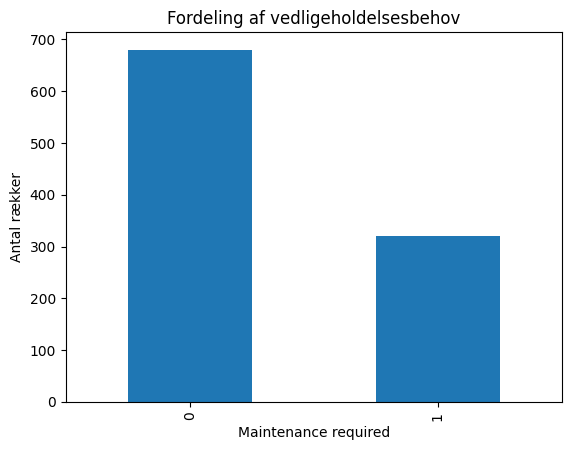

In [10]:
target_counts.plot(kind="bar")
plt.title("Fordeling af vedligeholdelsesbehov")
plt.xlabel("Maintenance required")
plt.ylabel("Antal rækker")
plt.show()

## 3. Valg af features

Modellen bruger operationelle features, der er relevante for vedligeholdelsesrisiko.

Vi udelader identifikatorer og beskrivende kolonner som `charger_id`, `location`, `charger_model`, `firmware_version` og `event_date`.

De kolonner er stadig vigtige til BI-filtrering og rapportering, men i den første ML-model fokuserer vi på numeriske operationelle indikatorer.

In [11]:
FEATURE_COLUMNS = [
    "avg_power_kw",
    "total_sessions_7d",
    "total_energy_kwh_7d",
    "fault_count_7d",
    "offline_minutes_7d",
    "failed_sessions_7d",
    "uptime_percentage",
    "anomaly_count_7d",
    "days_since_last_maintenance",
    "firmware_age_days",
    "temperature_avg_c",
]

TARGET_COLUMN = "maintenance_required"

X = data[FEATURE_COLUMNS]
y = data[TARGET_COLUMN]

X.head()

,avg_power_kw,total_sessions_7d,total_energy_kwh_7d,fault_count_7d,offline_minutes_7d,failed_sessions_7d,uptime_percentage,anomaly_count_7d,days_since_last_maintenance,firmware_age_days,temperature_avg_c
0,17.20,149,896.93,0,23,0,99.77,0,109,17,-6.9
1,7.58,160,691.20,0,37,0,99.63,0,2,82,17.1
2,18.43,196,2811.58,0,38,0,99.62,1,32,194,-5.2
3,21.73,69,1868.90,0,0,0,100.00,0,98,143,8.3
4,13.38,72,421.87,2,79,0,99.22,4,98,139,27.6


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Træningsrækker:", len(X_train))
print("Testrækker:", len(X_test))

Træningsrækker: 750
Testrækker: 250


## 4. Baseline-model: Logistic Regression

Vi starter med Logistic Regression som en simpel baseline-model.

En baseline-model er nyttig, fordi den giver et enkelt sammenligningsgrundlag. Hvis en mere avanceret model ikke præsterer bedre end baseline, er den ekstra kompleksitet måske ikke nødvendig.

In [13]:
baseline_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

In [14]:
print("Baseline: Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, baseline_predictions), 3))
print("Precision:", round(precision_score(y_test, baseline_predictions), 3))
print("Recall:", round(recall_score(y_test, baseline_predictions), 3))
print("F1-score:", round(f1_score(y_test, baseline_predictions), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, baseline_predictions))

print("\nClassification report:")
print(classification_report(y_test, baseline_predictions))

Baseline: Logistic Regression
Accuracy: 0.956
Precision: 0.96
Recall: 0.9
F1-score: 0.929

Confusion matrix:
[[167   3]
 [  8  72]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       170
           1       0.96      0.90      0.93        80

    accuracy                           0.96       250
   macro avg       0.96      0.94      0.95       250
weighted avg       0.96      0.96      0.96       250



## 5. Random Forest Classifier

Derefter træner vi en Random Forest Classifier.

Random Forest kan fange mere komplekse mønstre end Logistic Regression. Det kan være relevant, hvis vedligeholdelsesrisiko afhænger af kombinationer af signaler, fx både mange fejl og lav oppetid.

In [15]:
random_forest_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    random_state=42,
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

In [16]:
print("Random Forest Classifier")
print("Accuracy:", round(accuracy_score(y_test, rf_predictions), 3))
print("Precision:", round(precision_score(y_test, rf_predictions), 3))
print("Recall:", round(recall_score(y_test, rf_predictions), 3))
print("F1-score:", round(f1_score(y_test, rf_predictions), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification report:")
print(classification_report(y_test, rf_predictions))

Random Forest Classifier
Accuracy: 0.976
Precision: 1.0
Recall: 0.925
F1-score: 0.961

Confusion matrix:
[[170   0]
 [  6  74]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       170
           1       1.00      0.93      0.96        80

    accuracy                           0.98       250
   macro avg       0.98      0.96      0.97       250
weighted avg       0.98      0.98      0.98       250



## 6. Hvorfor recall er vigtig

I predictive maintenance er recall særligt vigtig.

Recall svarer på spørgsmålet:

> Af de ladestandere, der faktisk har forhøjet vedligeholdelsesrisiko, hvor mange finder modellen?

Lav recall betyder, at modellen overser ladestandere, der potentielt kan fejle eller kræve service. For VoltEdge kan det føre til mere nedetid, dårligere kundeoplevelse og mere manuel incident-håndtering.

In [17]:
model_comparison = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": accuracy_score(y_test, baseline_predictions),
            "precision": precision_score(y_test, baseline_predictions),
            "recall": recall_score(y_test, baseline_predictions),
            "f1_score": f1_score(y_test, baseline_predictions),
        },
        {
            "model": "Random Forest",
            "accuracy": accuracy_score(y_test, rf_predictions),
            "precision": precision_score(y_test, rf_predictions),
            "recall": recall_score(y_test, rf_predictions),
            "f1_score": f1_score(y_test, rf_predictions),
        },
    ]
)

model_comparison

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.956,0.96,0.900,0.929032
1,Random Forest,0.976,1.00,0.925,0.961039


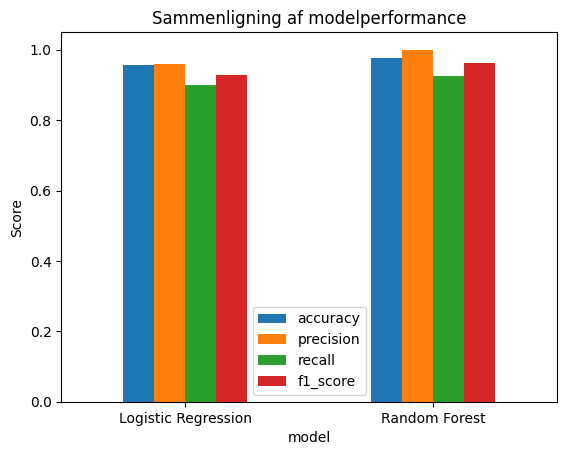

In [18]:
model_comparison.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar")
plt.title("Sammenligning af modelperformance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

## 7. Feature importance

Random Forest kan vise, hvilke features der har haft størst betydning for modellens forudsigelser.

Det gør modellen nemmere at forklare forretningmæssigt.

Hvis fx `fault_count_7d`, `offline_minutes_7d` og `uptime_percentage` er blandt de vigtigste features, passer modellen godt til den operationelle virkelighed omkring vedligeholdelse af ladestandere.

In [19]:
feature_importance = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance": random_forest_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance

,feature,importance
3,fault_count_7d,0.314226
4,offline_minutes_7d,0.175308
6,uptime_percentage,0.165099
5,failed_sessions_7d,0.163193
7,anomaly_count_7d,0.088062
9,firmware_age_days,0.024822
8,days_since_last_maintenance,0.023683
2,total_energy_kwh_7d,0.013693
10,temperature_avg_c,0.011490
0,avg_power_kw,0.010504


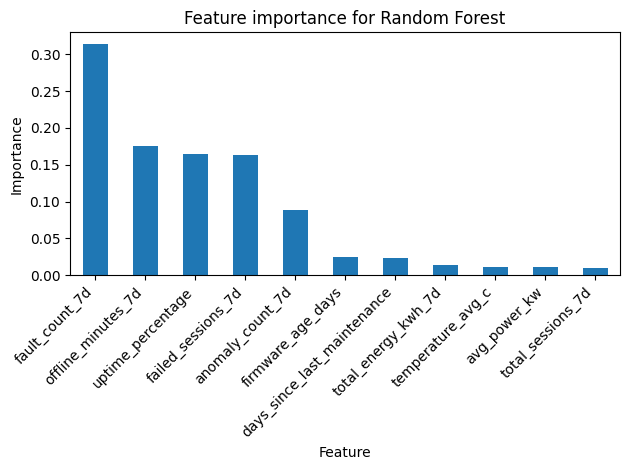

In [20]:
feature_importance.plot(
    kind="bar",
    x="feature",
    y="importance",
    legend=False,
)

plt.title("Feature importance for Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Tilføj forudsigelser til datasættet

For at gøre resultatet brugbart i Power BI tilføjer vi modellens forudsigelser tilbage til datasættet.

Det skaber et beriget datasæt, som kan visualiseres i dashboards.

In [21]:
enriched_data = data.copy()

enriched_data["predicted_maintenance_required"] = random_forest_model.predict(X)

if hasattr(random_forest_model, "predict_proba"):
    enriched_data["maintenance_risk_probability"] = random_forest_model.predict_proba(X)[:, 1]

enriched_data["maintenance_risk_level"] = pd.cut(
    enriched_data["maintenance_risk_probability"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["low", "medium", "high"],
)

enriched_data.head()

,event_date,charger_id,location,charger_model,firmware_version,avg_power_kw,total_sessions_7d,total_energy_kwh_7d,fault_count_7d,offline_minutes_7d,failed_sessions_7d,uptime_percentage,anomaly_count_7d,days_since_last_maintenance,firmware_age_days,temperature_avg_c,maintenance_required,predicted_maintenance_required,maintenance_risk_probability,maintenance_risk_level
0,2026-01-20,charger-082,Aarhus,VE-DC-150,1.0.2,17.20,149,896.93,0,23,0,99.77,0,109,17,-6.9,0,0,0.009111,low
1,2026-02-21,charger-072,Odense,VE-AC-22,1.1.0,7.58,160,691.20,0,37,0,99.63,0,2,82,17.1,0,0,0.000608,low
2,2026-02-09,charger-098,Roskilde,VE-DC-50,1.1.0,18.43,196,2811.58,0,38,0,99.62,1,32,194,-5.2,0,0,0.001019,low
3,2026-02-27,charger-091,Aarhus,VE-DC-50,1.2.4,21.73,69,1868.90,0,0,0,100.00,0,98,143,8.3,0,0,0.000764,low
4,2026-05-08,charger-027,Roskilde,VE-AC-22,1.2.4,13.38,72,421.87,2,79,0,99.22,4,98,139,27.6,0,0,0.065248,low


In [22]:
OUTPUT_PATH = Path("data/charger_maintenance_predictions.csv")

enriched_data.to_csv(OUTPUT_PATH, index=False)

print("Gemte beriget datasæt til:", OUTPUT_PATH)
print("Antal rækker:", len(enriched_data))

Gemte beriget datasæt til: data\charger_maintenance_predictions.csv
Antal rækker: 1000


## 9. Forretningsmæssig fortolkning

Modellen kan hjælpe VoltEdges operations-team med at prioritere ladestandere til inspektion.

I stedet for kun at reagere efter incidents opstår, kan platformen bruge operationelle signaler til at identificere ladestandere med forhøjet vedligeholdelsesrisiko.

Det understøtter:

- bedre oppetid
- færre manuelle incidents
- bedre kundeoplevelse
- mere datadrevet drift
- bedre SLA/KPI-rapportering

## 10. Relation til den tekniske MVP

FastAPI-applikationen demonstrerer den operationelle platform.

Analytics domain service leverer operationelle metrics som udnyttelse, energiforbrug og fejlrelaterede indsigter.

Denne notebook demonstrerer en separat predictive analytics-analyse baseret på historiske operationsdata.

I en senere produktionsversion kunne modellen:

1. eksponeres gennem den eksisterende analytics domain service,
2. deployes som en separat ML-service,
3. eller bruges til at berige et data warehouse til BI-dashboards.

## 11. Begrænsninger

Modellen er baseret på syntetiske data.

Resultatet skal derfor ikke forstås som en produktionsklar predictive maintenance-model.

Formålet er at demonstrere metoden og det arkitektoniske potentiale.

En reel produktionsversion ville kræve:

- rigtige historiske ladestanderdata
- reelle vedligeholdelsesregistreringer
- bedre feature engineering
- model monitoring
- strategi for retræning
- datakvalitetskontrol
- validering med driftseksperter